In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.preprocessing import StandardScaler


In [3]:
train_data = np.load('Data+Description\\fashion_train.npy')
test_data = np.load('Data+Description\\fashion_test.npy')

In [ ]:
print(train_data)
print(test_data)

In [7]:
train_data_X=train_data[:,:-1]
train_data_y=train_data[:,-1]

test_data_X=test_data[:,:-1]
test_data_y=test_data[:,-1]
train_data_X.shape

(10000, 784)

In [40]:
for i in range(100):
    print(i,':', train_data_y[i])

0 : 0
1 : 1
2 : 0
3 : 3
4 : 4
5 : 1
6 : 2
7 : 2
8 : 2
9 : 1
10 : 3
11 : 4
12 : 3
13 : 1
14 : 0
15 : 3
16 : 1
17 : 2
18 : 0
19 : 4
20 : 0
21 : 0
22 : 3
23 : 1
24 : 4
25 : 0
26 : 3
27 : 3
28 : 4
29 : 3
30 : 4
31 : 3
32 : 1
33 : 1
34 : 2
35 : 3
36 : 4
37 : 2
38 : 3
39 : 3
40 : 0
41 : 3
42 : 1
43 : 3
44 : 0
45 : 1
46 : 1
47 : 2
48 : 4
49 : 0
50 : 4
51 : 4
52 : 3
53 : 4
54 : 3
55 : 0
56 : 4
57 : 2
58 : 3
59 : 4
60 : 3
61 : 4
62 : 3
63 : 1
64 : 2
65 : 4
66 : 2
67 : 2
68 : 3
69 : 2
70 : 3
71 : 2
72 : 4
73 : 3
74 : 1
75 : 4
76 : 3
77 : 0
78 : 1
79 : 0
80 : 0
81 : 0
82 : 3
83 : 4
84 : 1
85 : 3
86 : 3
87 : 2
88 : 4
89 : 0
90 : 1
91 : 2
92 : 4
93 : 4
94 : 1
95 : 0
96 : 4
97 : 1
98 : 1
99 : 1


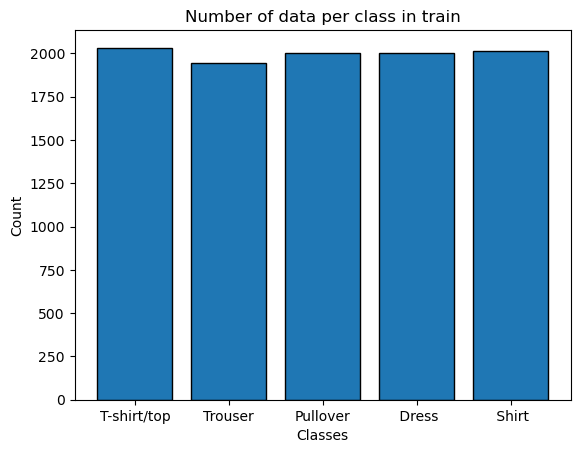

In [4]:
categories = ['T-shirt/top', 'Trouser', 'Pullover', ' Dress', ' Shirt']

# Plot the histogram
plt.hist(train_data_y, bins=np.arange(6)-0.5, edgecolor='black', rwidth=0.8)

# Set the x-ticks to the class names
plt.xticks(ticks=np.arange(5), labels=categories)

# Add labels and title
plt.xlabel('Classes')
plt.ylabel('Count')
plt.title('Number of data per class in train')

# Show the plot
plt.show()

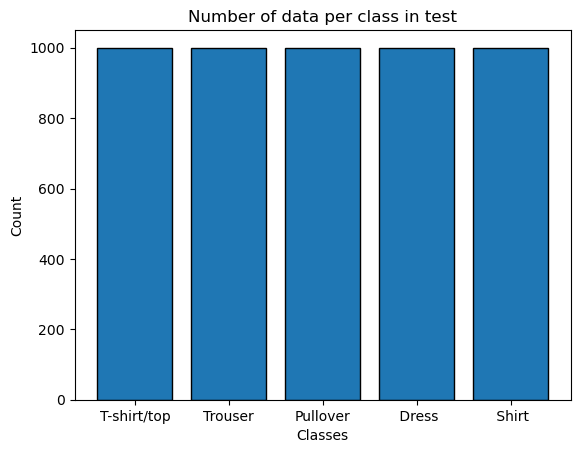

In [8]:
categories = ['T-shirt/top', 'Trouser', 'Pullover', ' Dress', ' Shirt']

# Plot the histogram
plt.hist(test_data_y, bins=np.arange(6)-0.5, edgecolor='black', rwidth=0.8)

# Set the x-ticks to the class names
plt.xticks(ticks=np.arange(5), labels=categories)

# Add labels and title
plt.xlabel('Classes')
plt.ylabel('Count')
plt.title('Number of data per class in test')

# Show the plot
plt.show()

[2033 1947 2001 2005 2014]


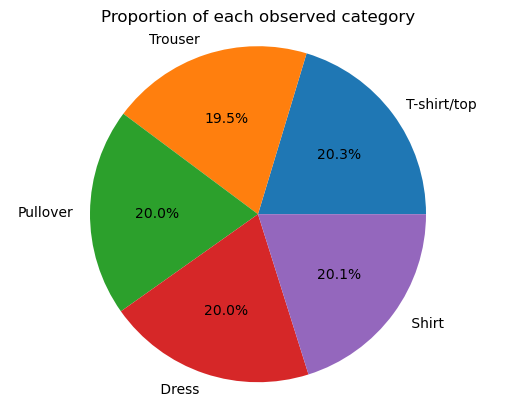

In [6]:
_, tc=np.unique(train_data_y, return_counts=True)
print(tc)
plt.pie(tc,
        explode=(0, 0, 0, 0, 0) , 
        labels=categories,
        autopct='%1.1f%%')
plt.axis('equal')
plt.title('Proportion of each observed category')
plt.show()

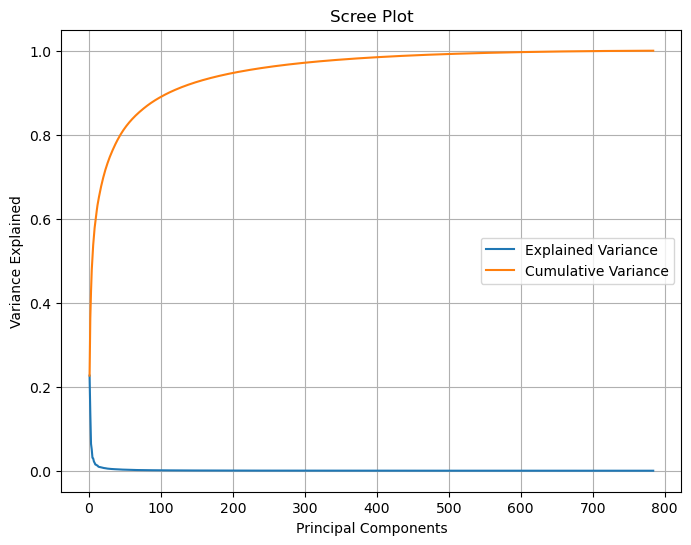

In [23]:
#PCA

scaler = StandardScaler()
image_scaled = scaler.fit_transform(train_data_X)

# Step 4: Apply PCA
pca = PCA()
pca.fit(image_scaled)

# Step 5: Scree plot - Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, label='Explained Variance')
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, label='Cumulative Variance')
plt.title('Scree Plot')
plt.xlabel('Principal Components')
plt.ylabel('Variance Explained')
plt.legend(loc='best')
plt.grid(True)
plt.show()

Напразни експерименти. Надолу има само мъка и човешко страдание.

In [ ]:
print("Component | Cumulative Variance")
for i, var in enumerate(cumulative_variance):
    print(f"    {i+1}     |    {var:.4f}")
    

In [ ]:
var_cumu = np.cumsum(pca.explained_variance_ratio_)*100
print(var_cumu)

In [144]:
images=np.array([[train_data_X[0],train_data_X[2],train_data_X[14],train_data_X[18]], #T-shirts/tops
                 [train_data_X[1],train_data_X[5],train_data_X[9],train_data_X[13]], #Trousers
                 [train_data_X[6],train_data_X[7],train_data_X[8],train_data_X[17]], #Pullovers
                 [train_data_X[3],train_data_X[10],train_data_X[12],train_data_X[15]], #Dresses
                 [train_data_X[4],train_data_X[11],train_data_X[19],train_data_X[24]]]) #Shirts
#images[4,2]


In [138]:
images=np.array([train_data_X[0], #T-shirts/tops
                 train_data_X[1], #Trousers
                 train_data_X[6], #Pullovers
                 train_data_X[3], #Dresses
                 train_data_X[4]]) #Shirts
images[4,2]

0

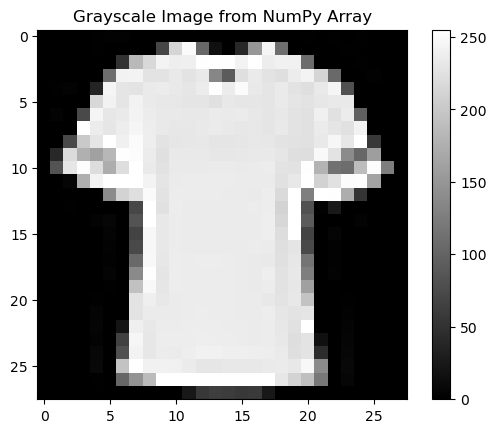

In [38]:
plt.imshow(test_data_X[1].reshape(28,28), cmap='gray')  # cmap='gray' ensures it's displayed as grayscale
plt.colorbar()  # Show the color scale
plt.title('Grayscale Image from NumPy Array')
plt.show()

c:\Users\user\anaconda3\Lib\site-packages\sklearn\decomposition\_pca.py:541: RuntimeWarning: invalid value encountered in divide
  explained_variance_ = (S**2) / (n_samples - 1)
c:\Users\user\anaconda3\Lib\site-packages\sklearn\decomposition\_pca.py:541: RuntimeWarning: invalid value encountered in divide
  explained_variance_ = (S**2) / (n_samples - 1)
c:\Users\user\anaconda3\Lib\site-packages\sklearn\decomposition\_pca.py:541: RuntimeWarning: invalid value encountered in divide
  explained_variance_ = (S**2) / (n_samples - 1)
c:\Users\user\anaconda3\Lib\site-packages\sklearn\decomposition\_pca.py:541: RuntimeWarning: invalid value encountered in divide
  explained_variance_ = (S**2) / (n_samples - 1)
c:\Users\user\anaconda3\Lib\site-packages\sklearn\decomposition\_pca.py:541: RuntimeWarning: invalid value encountered in divide
  explained_variance_ = (S**2) / (n_samples - 1)


!!! 0.6
!!! 0.81
!!! 0.89
!!! 0.96
!!! 1


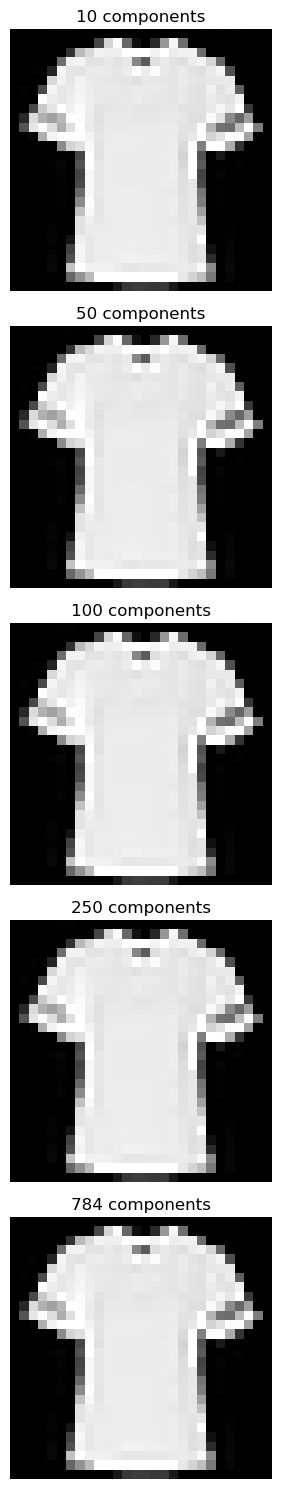

In [21]:
scaler = StandardScaler()

cumulative_variance_list = [0.60, 0.81, 0.89, 0.96, 1]
components_list = [10, 50, 100, 250, 784]
fig, axes = plt.subplots(5, figsize=(15, 15))

for i, n_components in enumerate(cumulative_variance_list):

    # Reduce dimensions with the given number of components
    pca_n = PCA(n_components=n_components)
    fig= plt.plot( figsize=(15, 15))
    # Plot the reconstructed image
    #for j in range(5):
    image=scaler.fit_transform(test_data_X[1].reshape(1, -1))
    reduced_image = pca_n.fit_transform(image)#.reshape(1, -1))
    #    print(reduced_image)
    #    print("!", j)
        # Reconstruct the image from the reduced components
    reconstructed_image = pca_n.inverse_transform(reduced_image)
        
        # Rescale back to original range
    reconstructed_image_rescaled = scaler.inverse_transform(reconstructed_image)

        # Reshape back to original image shape
    image_reconstructed = reconstructed_image_rescaled.reshape(28,28)
            
    ax = axes[i]
    ax.imshow(image_reconstructed, cmap='gray')
    
    ax.set_title(f"{components_list[i]} components")
    ax.axis('off')
    print("!!!", n_components)
# Show the plots
plt.tight_layout()
plt.show()

In [44]:
k = np.argmax(var_cumu>99)
print("Number of components explaining 95% variance: "+ str(k))
#print("\n")

Number of components explaining 95% variance: 465


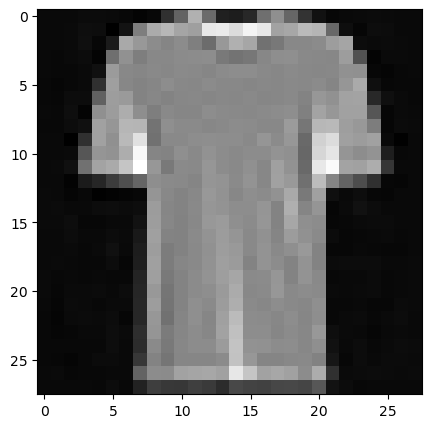

In [45]:
ipca = IncrementalPCA(n_components=k)
image_recon = ipca.inverse_transform(ipca.fit_transform(train_data_X))[0].reshape(28,28)
plt.figure(figsize=[5,5])
plt.imshow(image_recon,cmap = plt.cm.gray)

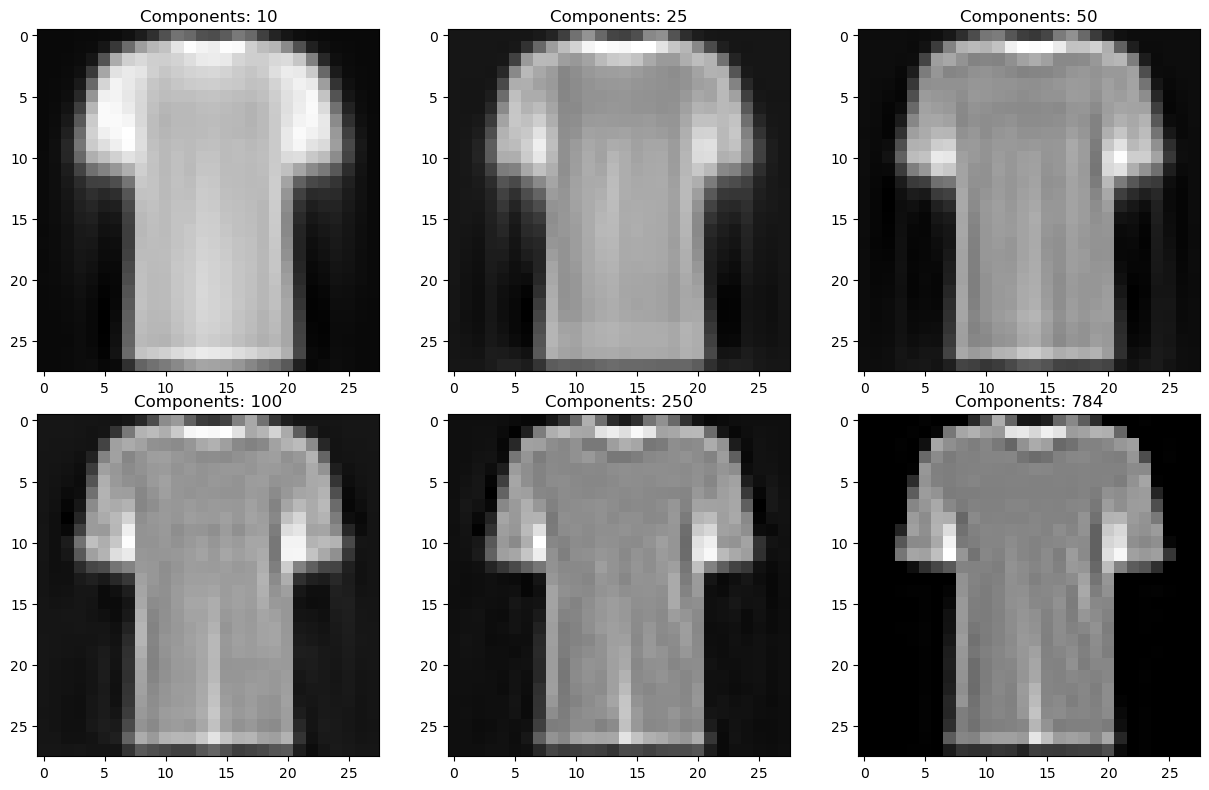

In [46]:
def plot_at_k(k):
    ipca = IncrementalPCA(n_components=k)
    image_recon = ipca.inverse_transform(ipca.fit_transform(train_data_X))[0].reshape(28,28)
    plt.imshow(image_recon,cmap = plt.cm.gray)

ks = [10, 25, 50, 100, 250, 784]
plt.figure(figsize=[15,10])

for i in range(6):
    plt.subplot(2,3,i+1)
    plot_at_k(ks[i])
    plt.title("Components: "+str(ks[i]))

plt.subplots_adjust(wspace=0.2, hspace=0.0)
plt.show()

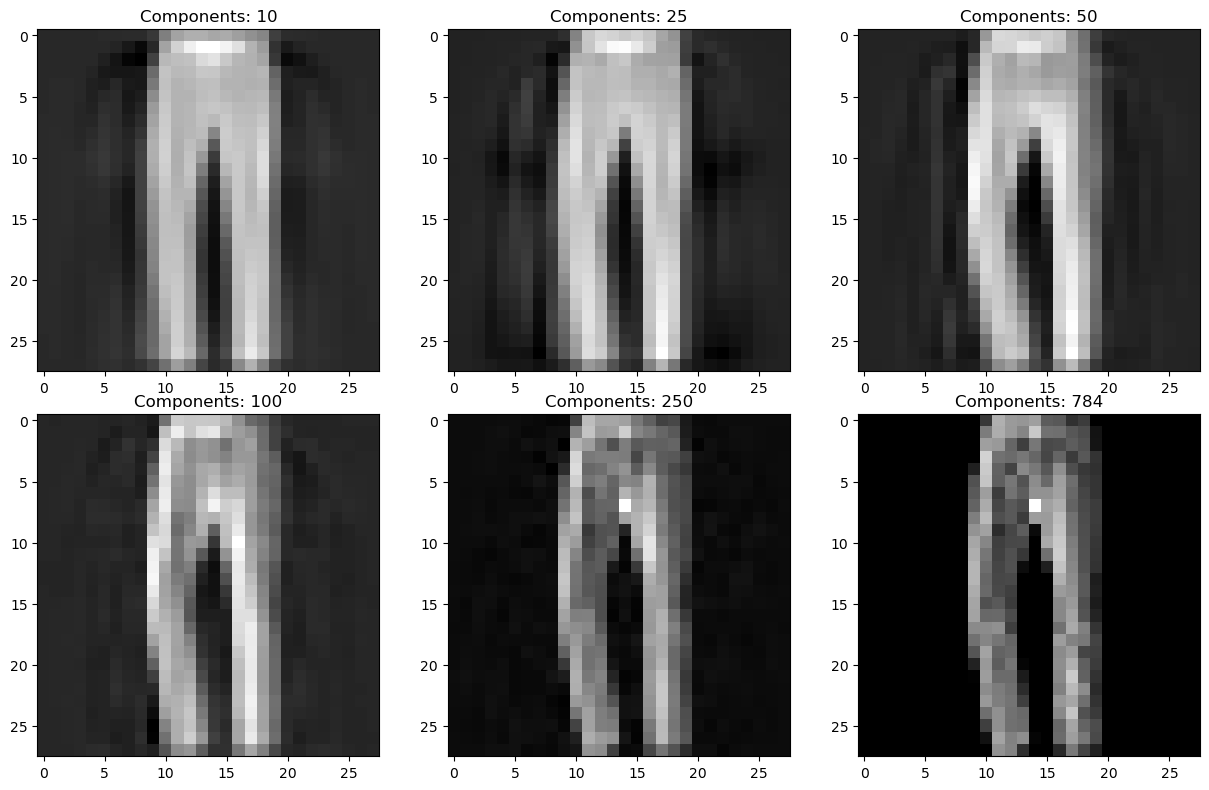

In [47]:
def plot_at_k(k):
    ipca = IncrementalPCA(n_components=k)
    image_recon = ipca.inverse_transform(ipca.fit_transform(train_data_X))[1].reshape(28,28)
    plt.imshow(image_recon,cmap = plt.cm.gray)

ks = [10, 25, 50, 100, 250, 784]
plt.figure(figsize=[15,10])

for i in range(6):
    plt.subplot(2,3,i+1)
    plot_at_k(ks[i])
    plt.title("Components: "+str(ks[i]))

plt.subplots_adjust(wspace=0.2, hspace=0.0)
plt.show()

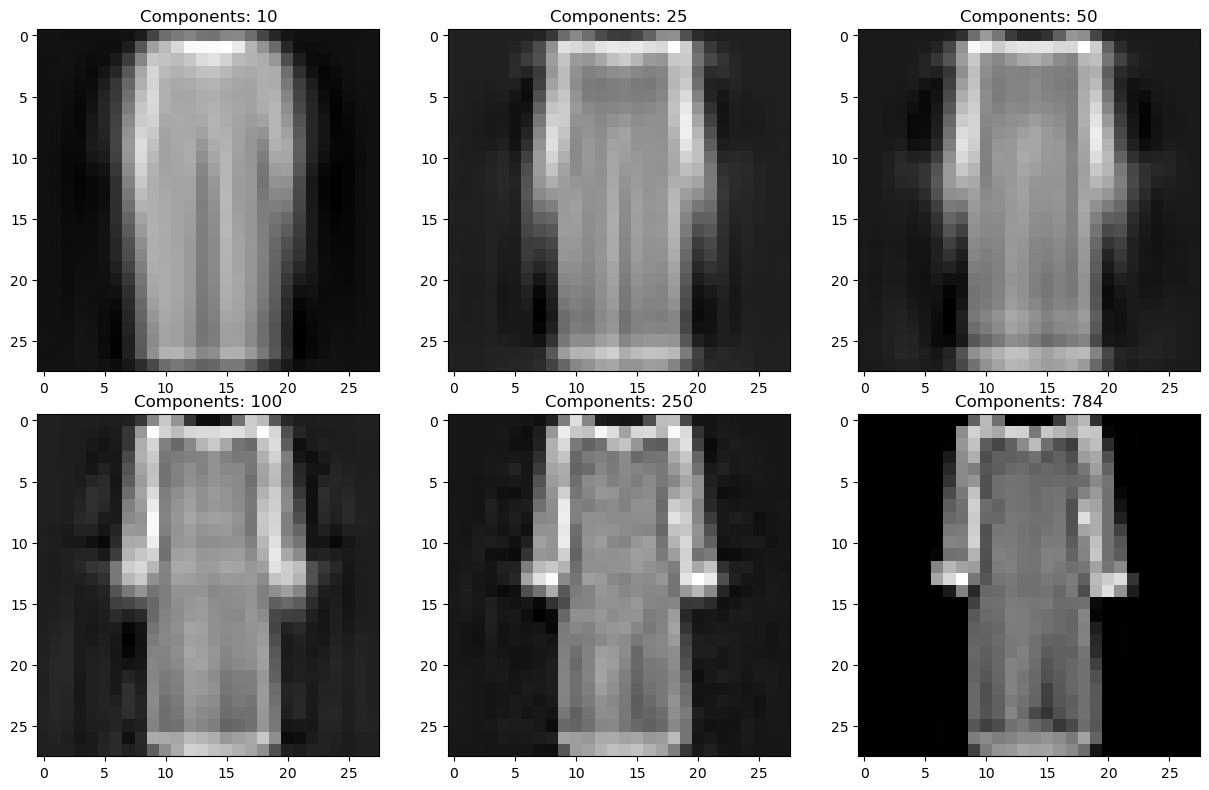

In [48]:
def plot_at_k(k):
    ipca = IncrementalPCA(n_components=k)
    image_recon = ipca.inverse_transform(ipca.fit_transform(train_data_X))[3].reshape(28,28)
    plt.imshow(image_recon,cmap = plt.cm.gray)

ks = [10, 25, 50, 100, 250, 784]
plt.figure(figsize=[15,10])

for i in range(6):
    plt.subplot(2,3,i+1)
    plot_at_k(ks[i])
    plt.title("Components: "+str(ks[i]))

plt.subplots_adjust(wspace=0.2, hspace=0.0)
plt.show()

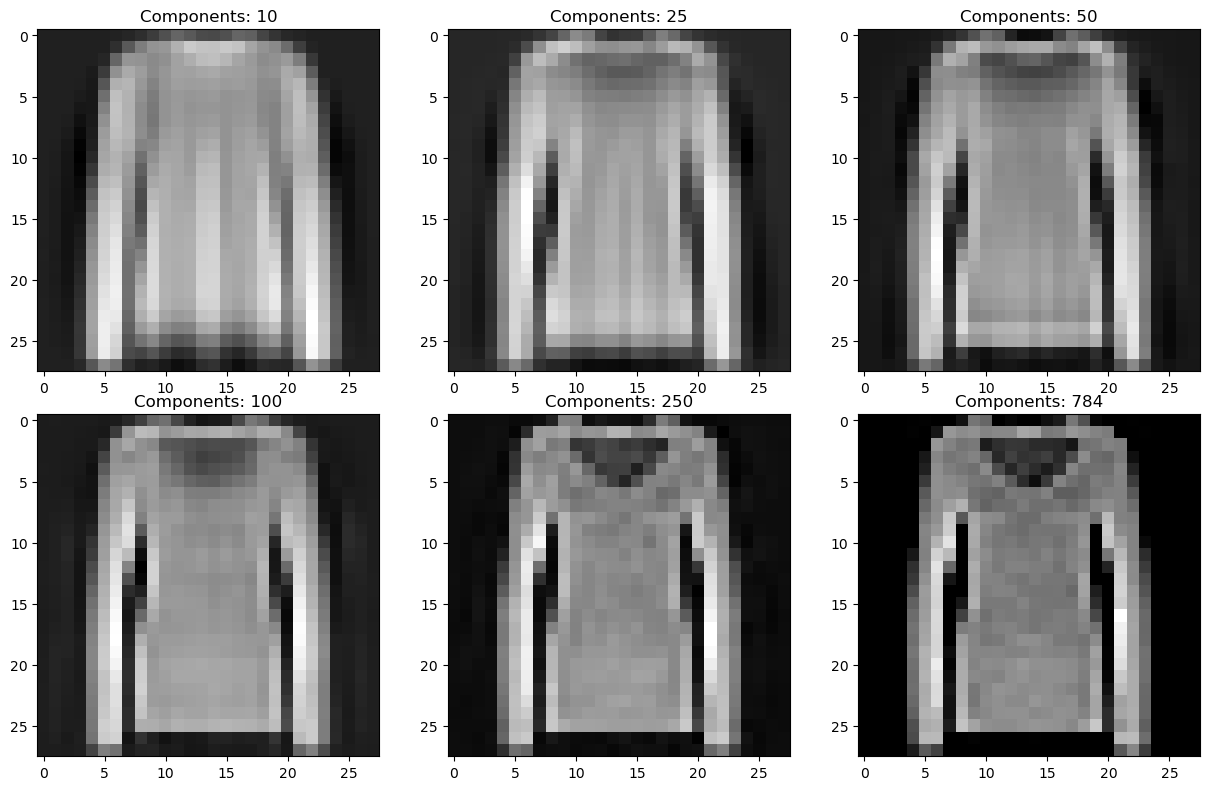

In [49]:
def plot_at_k(k):
    ipca = IncrementalPCA(n_components=k)
    image_recon = ipca.inverse_transform(ipca.fit_transform(train_data_X))[6].reshape(28,28)
    plt.imshow(image_recon,cmap = plt.cm.gray)

ks = [10, 25, 50, 100, 250, 784]
plt.figure(figsize=[15,10])

for i in range(6):
    plt.subplot(2,3,i+1)
    plot_at_k(ks[i])
    plt.title("Components: "+str(ks[i]))

plt.subplots_adjust(wspace=0.2, hspace=0.0)
plt.show()

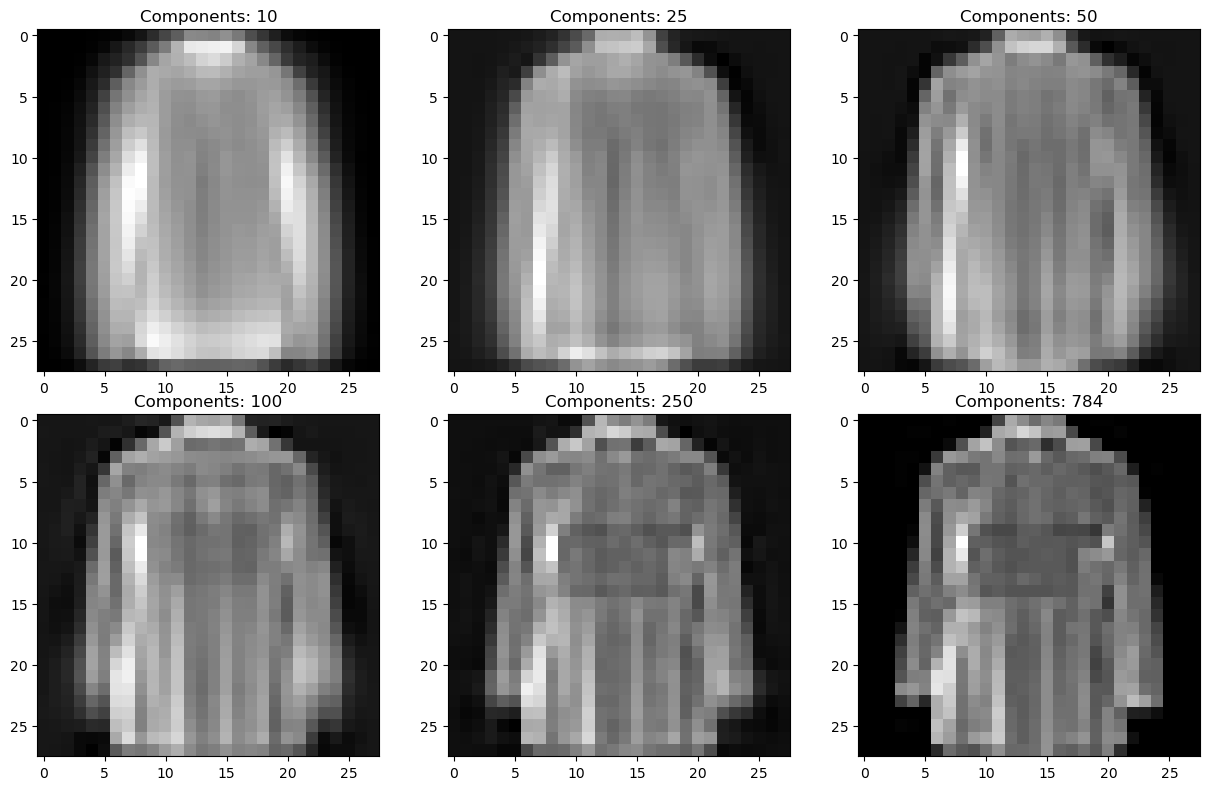

In [50]:
def plot_at_k(k):
    ipca = IncrementalPCA(n_components=k)
    image_recon = ipca.inverse_transform(ipca.fit_transform(train_data_X))[4].reshape(28,28)
    plt.imshow(image_recon,cmap = plt.cm.gray)

ks = [10, 25, 50, 100, 250, 784]
plt.figure(figsize=[15,10])

for i in range(6):
    plt.subplot(2,3,i+1)
    plot_at_k(ks[i])
    plt.title("Components: "+str(ks[i]))

plt.subplots_adjust(wspace=0.2, hspace=0.0)
plt.show()